   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.6 MB/s eta 0:00:00
GA Results: [0.9648148148148148, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.9907407407407407, 0.99074

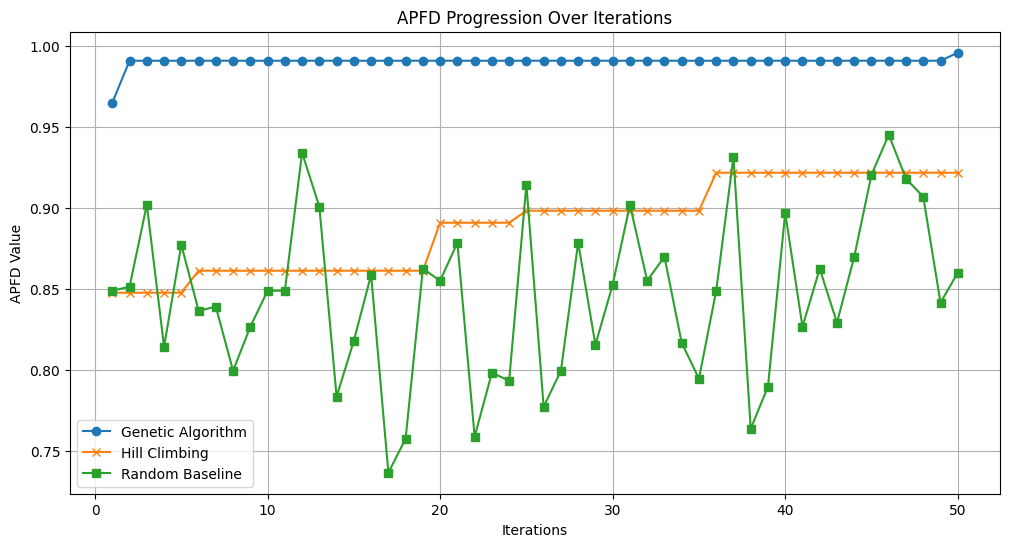

In [ ]:
!pip install deap
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Step 1: Parse dataset
def parse_fault_matrix(file_path):
    with open(file_path, 'r') as file:
        fault_matrix = []
        for line in file:
            parts = line.strip().split(',')
            test_id = parts[0]
            faults = list(map(int, parts[1:]))
            fault_matrix.append((test_id, faults))
    return fault_matrix

# Calculate APFD
def calculate_apfd(order, fault_matrix):
    total_faults = len(fault_matrix[0][1])
    num_tests = len(order)
    found = np.zeros(total_faults)
    fault_detected = 0
    cumulative_sum = 0

    for i, test_index in enumerate(order):
        test_faults = fault_matrix[test_index][1]
        for fault_index in range(total_faults):
            if test_faults[fault_index] == 1 and found[fault_index] == 0:
                found[fault_index] = 1
                fault_detected += 1
                cumulative_sum += (i + 1)

    apfd = 1 - (cumulative_sum / (num_tests * total_faults)) + (1 / (2 * num_tests))
    return apfd

# Step 3: Genetic Algorithm implementation
def run_genetic_algorithm(fault_matrix, population_size=20, generations=50, crossover_prob=0.7, mutation_prob=0.2):
    num_tests = len(fault_matrix)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("indices", random.sample, range(num_tests), num_tests)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def evaluate(individual):
        return calculate_apfd(individual, fault_matrix),

    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", evaluate)

    population = toolbox.population(n=population_size)
    results_per_generation = []

    for gen in range(generations):
        algorithms.eaSimple(population, toolbox, cxpb=crossover_prob, mutpb=mutation_prob, ngen=1, verbose=False)
        best_individual = tools.selBest(population, k=1)[0]
        apfd_value = calculate_apfd(best_individual, fault_matrix)
        results_per_generation.append(apfd_value)

    return results_per_generation

# Step 4: Hill Climbing implementation
def run_hill_climber(fault_matrix, iterations=50):
    num_tests = len(fault_matrix)
    current_solution = list(range(num_tests))
    random.shuffle(current_solution)

    current_fitness = calculate_apfd(current_solution, fault_matrix)
    results_per_iteration = [current_fitness]

    for _ in range(1, iterations):
        neighbor = current_solution[:]
        i, j = random.sample(range(num_tests), 2)
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        neighbor_fitness = calculate_apfd(neighbor, fault_matrix)
        if neighbor_fitness > current_fitness:
            current_solution, current_fitness = neighbor, neighbor_fitness

        results_per_iteration.append(current_fitness)

    return results_per_iteration

# Step 5: Compare with Random Baseline
def random_baseline(fault_matrix, iterations=50):
    num_tests = len(fault_matrix)
    results_per_iteration = []

    for _ in range(iterations):
        random_order = list(range(num_tests))
        random.shuffle(random_order)
        apfd = calculate_apfd(random_order, fault_matrix)
        results_per_iteration.append(apfd)

    return results_per_iteration

# Step 6: Plot Results (Line Plot)
def plot_line_results(ga_results, hill_climb_results, random_results, iterations):
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, iterations + 1), ga_results, label='Genetic Algorithm', marker='o')
    plt.plot(range(1, iterations + 1), hill_climb_results, label='Hill Climbing', marker='x')
    plt.plot(range(1, iterations + 1), random_results, label='Random Baseline', marker='s')
    plt.title("APFD Progression Over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("APFD Value")
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

# Main execution
if __name__ == "__main__":
    # Load the fault matrix data
    fault_matrix = parse_fault_matrix("/content/newsmallfaultmatrix.txt")

    # Number of iterations for the line plot
    iterations = 50

    # Run Genetic Algorithm
    ga_results = run_genetic_algorithm(fault_matrix, generations=iterations)
    print(f"GA Results: {ga_results}")

    # Run Hill Climbing
    hill_climb_results = run_hill_climber(fault_matrix, iterations=iterations)
    print(f"Hill Climbing Results: {hill_climb_results}")

    # Random Baseline
    random_results = random_baseline(fault_matrix, iterations=iterations)
    print(f"Random Baseline Results: {random_results}")

    # Plot the line results
    plot_line_results(ga_results, hill_climb_results, random_results, iterations)


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


GA Results: [0.9431328982085821, 0.9409109845854742, 0.945910290237467, 0.945910290237467, 0.945910290237467, 0.945910290237467, 0.9479238994584085, 0.948201638661297, 0.9507707262880155, 0.9495903346757395, 0.9495903346757395, 0.9513956394945147, 0.9545202055270101, 0.9545202055270101, 0.9554922927371198, 0.9557700319400083, 0.9575059019580614, 0.9602138591862242, 0.9620885988057214, 0.9631995556172753, 0.9620885988057214, 0.9620885988057214, 0.9625052076100541, 0.9625052076100541, 0.9625052076100541, 0.9625052076100541, 0.966393556450493, 0.966393556450493, 0.966393556450493, 0.966393556450493, 0.966393556450493, 0.966393556450493, 0.966393556450493, 0.9667407304541036, 0.9667407304541036, 0.9667407304541036, 0.9667407304541036, 0.9679905568671018, 0.9716706013053742, 0.9722260797111512, 0.9722260797111512, 0.972712123316206, 0.972712123316206, 0.972712123316206, 0.972712123316206, 0.972712123316206, 0.9728509929176503, 0.9728509929176503, 0.9733370365227051, 0.9733370365227051]
Hill

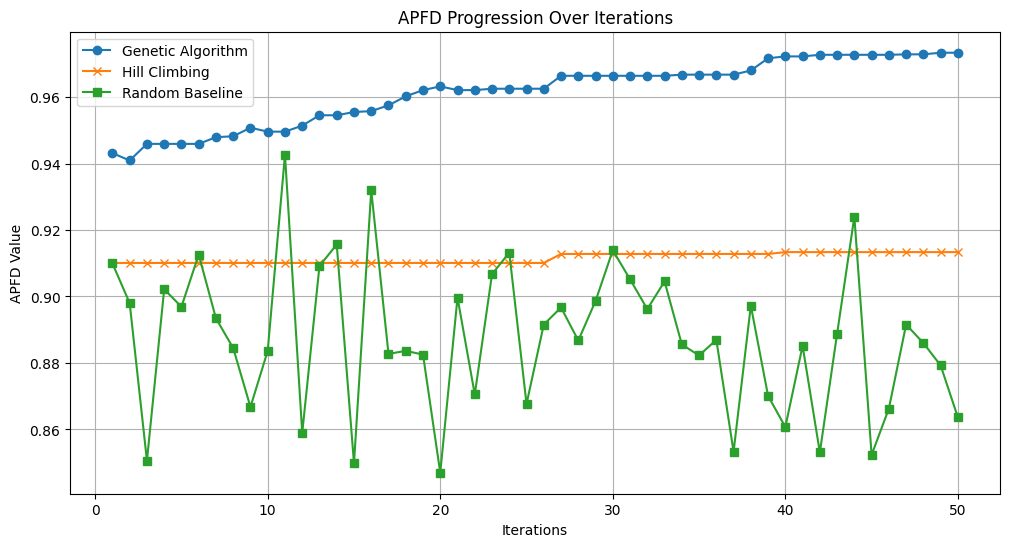

In [ ]:
!pip install deap
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Step 1: Parse dataset
def parse_fault_matrix(file_path):
    with open(file_path, 'r') as file:
        fault_matrix = []
        for line in file:
            parts = line.strip().split(',')
            test_id = parts[0]
            faults = list(map(int, parts[1:]))
            fault_matrix.append((test_id, faults))
    return fault_matrix

# Calculate APFD
def calculate_apfd(order, fault_matrix):
    total_faults = len(fault_matrix[0][1])
    num_tests = len(order)
    found = np.zeros(total_faults)
    fault_detected = 0
    cumulative_sum = 0

    for i, test_index in enumerate(order):
        test_faults = fault_matrix[test_index][1]
        for fault_index in range(total_faults):
            if test_faults[fault_index] == 1 and found[fault_index] == 0:
                found[fault_index] = 1
                fault_detected += 1
                cumulative_sum += (i + 1)

    apfd = 1 - (cumulative_sum / (num_tests * total_faults)) + (1 / (2 * num_tests))
    return apfd

# Step 3: Genetic Algorithm implementation
def run_genetic_algorithm(fault_matrix, population_size=20, generations=50, crossover_prob=0.7, mutation_prob=0.2):
    num_tests = len(fault_matrix)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("indices", random.sample, range(num_tests), num_tests)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def evaluate(individual):
        return calculate_apfd(individual, fault_matrix),

    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", evaluate)

    population = toolbox.population(n=population_size)
    results_per_generation = []

    for gen in range(generations):
        algorithms.eaSimple(population, toolbox, cxpb=crossover_prob, mutpb=mutation_prob, ngen=1, verbose=False)
        best_individual = tools.selBest(population, k=1)[0]
        apfd_value = calculate_apfd(best_individual, fault_matrix)
        results_per_generation.append(apfd_value)

    return results_per_generation

# Step 4: Hill Climbing implementation
def run_hill_climber(fault_matrix, iterations=50):
    num_tests = len(fault_matrix)
    current_solution = list(range(num_tests))
    random.shuffle(current_solution)

    current_fitness = calculate_apfd(current_solution, fault_matrix)
    results_per_iteration = [current_fitness]

    for _ in range(1, iterations):
        neighbor = current_solution[:]
        i, j = random.sample(range(num_tests), 2)
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        neighbor_fitness = calculate_apfd(neighbor, fault_matrix)
        if neighbor_fitness > current_fitness:
            current_solution, current_fitness = neighbor, neighbor_fitness

        results_per_iteration.append(current_fitness)

    return results_per_iteration

# Step 5: Compare with Random Baseline
def random_baseline(fault_matrix, iterations=50):
    num_tests = len(fault_matrix)
    results_per_iteration = []

    for _ in range(iterations):
        random_order = list(range(num_tests))
        random.shuffle(random_order)
        apfd = calculate_apfd(random_order, fault_matrix)
        results_per_iteration.append(apfd)

    return results_per_iteration

# Step 6: Plot Results (Line Plot)
def plot_line_results(ga_results, hill_climb_results, random_results, iterations):
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, iterations + 1), ga_results, label='Genetic Algorithm', marker='o')
    plt.plot(range(1, iterations + 1), hill_climb_results, label='Hill Climbing', marker='x')
    plt.plot(range(1, iterations + 1), random_results, label='Random Baseline', marker='s')
    plt.title("APFD Progression Over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("APFD Value")
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

# Main execution
if __name__ == "__main__":
    # Load the fault matrix data
    fault_matrix = parse_fault_matrix("/content/newbigfaultmatrix.txt")

    # Number of iterations for the line plot
    iterations = 50

    # Run Genetic Algorithm
    ga_results = run_genetic_algorithm(fault_matrix, generations=iterations)
    print(f"GA Results: {ga_results}")

    # Run Hill Climbing
    hill_climb_results = run_hill_climber(fault_matrix, iterations=iterations)
    print(f"Hill Climbing Results: {hill_climb_results}")

    # Random Baseline
    random_results = random_baseline(fault_matrix, iterations=iterations)
    print(f"Random Baseline Results: {random_results}")

    # Plot the line results
    plot_line_results(ga_results, hill_climb_results, random_results, iterations)


GA Results: [0.9635802469135802, 0.9635802469135802, 0.9635802469135802, 0.9660493827160493, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9759259259259259, 0.9820987654320987, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9845679012345678, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.9858024691358025, 0.98580

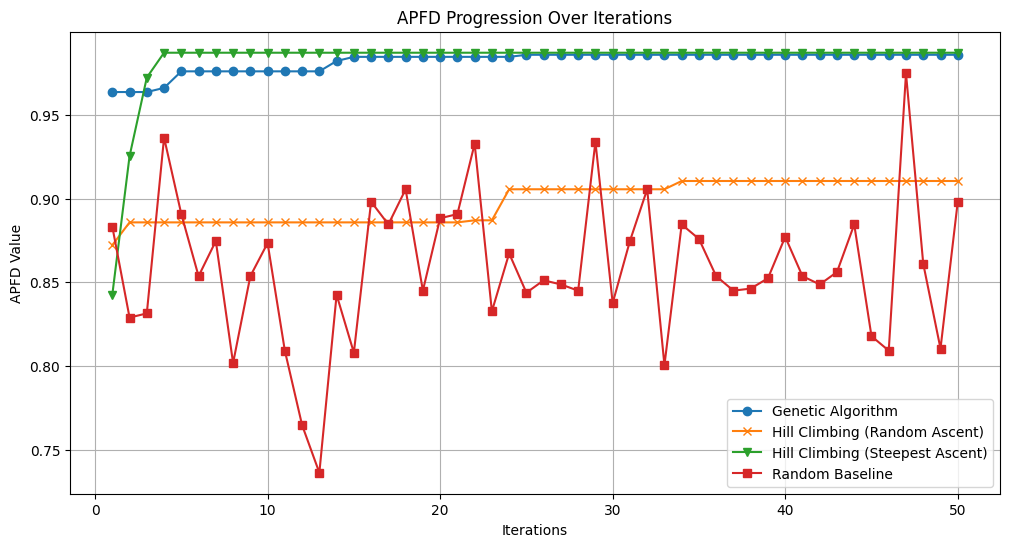

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Step 1: Parse dataset
def parse_fault_matrix(file_path):
    with open(file_path, 'r') as file:
        fault_matrix = []
        for line in file:
            parts = line.strip().split(',')
            test_id = parts[0]
            faults = list(map(int, parts[1:]))
            fault_matrix.append((test_id, faults))
    return fault_matrix

# Calculate APFD
def calculate_apfd(order, fault_matrix):
    total_faults = len(fault_matrix[0][1])
    num_tests = len(order)
    found = np.zeros(total_faults)
    fault_detected = 0
    cumulative_sum = 0

    for i, test_index in enumerate(order):
        test_faults = fault_matrix[test_index][1]
        for fault_index in range(total_faults):
            if test_faults[fault_index] == 1 and found[fault_index] == 0:
                found[fault_index] = 1
                fault_detected += 1
                cumulative_sum += (i + 1)

    apfd = 1 - (cumulative_sum / (num_tests * total_faults)) + (1 / (2 * num_tests))
    return apfd

# Step 3: Genetic Algorithm implementation
def run_genetic_algorithm(fault_matrix, population_size=20, generations=50, crossover_prob=0.7, mutation_prob=0.2):
    num_tests = len(fault_matrix)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("indices", random.sample, range(num_tests), num_tests)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def evaluate(individual):
        return calculate_apfd(individual, fault_matrix),

    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", evaluate)

    population = toolbox.population(n=population_size)
    results_per_generation = []

    for gen in range(generations):
        algorithms.eaSimple(population, toolbox, cxpb=crossover_prob, mutpb=mutation_prob, ngen=1, verbose=False)
        best_individual = tools.selBest(population, k=1)[0]
        apfd_value = calculate_apfd(best_individual, fault_matrix)
        results_per_generation.append(apfd_value)

    return results_per_generation

# Step 4: Hill Climbing implementation with choice of neighborhood strategy
def run_hill_climber(fault_matrix, iterations=50, strategy='random'):
    """
    Run the Hill Climber algorithm on the fault matrix with the given strategy.

    Parameters:
        fault_matrix (list): The fault matrix data.
        iterations (int): Number of iterations to run.
        strategy (str): The hill climbing strategy to use ('random' or 'steepest').

    Returns:
        list: APFD values at each iteration.
    """
    num_tests = len(fault_matrix)
    current_solution = list(range(num_tests))
    random.shuffle(current_solution)

    current_fitness = calculate_apfd(current_solution, fault_matrix)
    results_per_iteration = [current_fitness]

    for _ in range(1, iterations):
        if strategy == 'random':
            # Random Ascent: Select a random neighbor and move to it if it's better
            neighbor = current_solution[:]
            i, j = random.sample(range(num_tests), 2)
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

            neighbor_fitness = calculate_apfd(neighbor, fault_matrix)
            if neighbor_fitness > current_fitness:
                current_solution, current_fitness = neighbor, neighbor_fitness

        elif strategy == 'steepest':
            # Steepest Ascent: Evaluate all neighbors and choose the best one
            best_neighbor = current_solution[:]
            best_fitness = current_fitness

            for i in range(num_tests):
                for j in range(i + 1, num_tests):
                    # Create a new neighbor by swapping elements i and j
                    neighbor = current_solution[:]
                    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

                    # Calculate the fitness of this neighbor
                    neighbor_fitness = calculate_apfd(neighbor, fault_matrix)
                    if neighbor_fitness > best_fitness:
                        best_neighbor, best_fitness = neighbor, neighbor_fitness

            if best_fitness > current_fitness:
                current_solution, current_fitness = best_neighbor, best_fitness

        # Record the current fitness value
        results_per_iteration.append(current_fitness)

    return results_per_iteration


# Step 5: Compare with Random Baseline
def random_baseline(fault_matrix, iterations=50):
    num_tests = len(fault_matrix)
    results_per_iteration = []

    for _ in range(iterations):
        random_order = list(range(num_tests))
        random.shuffle(random_order)
        apfd = calculate_apfd(random_order, fault_matrix)
        results_per_iteration.append(apfd)

    return results_per_iteration

# Step 6: Plot Results (Line Plot) including both strategies
def plot_line_results(ga_results, hill_climb_results_random, hill_climb_results_steepest, random_results, iterations):
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, iterations + 1), ga_results, label='Genetic Algorithm', marker='o')
    plt.plot(range(1, iterations + 1), hill_climb_results_random, label='Hill Climbing (Random Ascent)', marker='x')
    plt.plot(range(1, iterations + 1), hill_climb_results_steepest, label='Hill Climbing (Steepest Ascent)', marker='v')
    plt.plot(range(1, iterations + 1), random_results, label='Random Baseline', marker='s')
    plt.title("APFD Progression Over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("APFD Value")
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

if __name__ == "__main__":
    # Load the fault matrix data
    fault_matrix = parse_fault_matrix("/content/newsmallfaultmatrix.txt")

    # Number of iterations for the line plot
    iterations = 50

    # Run Genetic Algorithm
    ga_results = run_genetic_algorithm(fault_matrix, generations=iterations)
    print(f"GA Results: {ga_results}")

    # Run Hill Climbing with Random Ascent
    hill_climb_results_random = run_hill_climber(fault_matrix, iterations=iterations, strategy='random')
    print(f"Hill Climbing (Random Ascent) Results: {hill_climb_results_random}")

    # Run Hill Climbing with Steepest Ascent
    hill_climb_results_steepest = run_hill_climber(fault_matrix, iterations=iterations, strategy='steepest')
    print(f"Hill Climbing (Steepest Ascent) Results: {hill_climb_results_steepest}")

    # Random Baseline
    random_results = random_baseline(fault_matrix, iterations=iterations)
    print(f"Random Baseline Results: {random_results}")

    # Plot the line results
    plot_line_results(ga_results, hill_climb_results_random, hill_climb_results_steepest, random_results, iterations)


Final Code

Final code